In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('clean_data.csv')

<b> Note: <i>Attrition</i> is the target feature</b>

## 1. Attrition Distribution

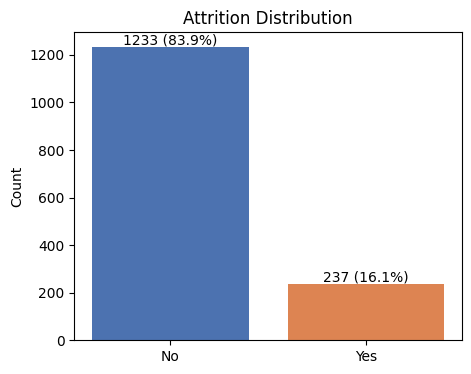

In [3]:
counts = df['Attrition'].value_counts()
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(counts.index, counts.values, color=['#4C72B0','#DD8452'])
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, f"{v} ({v/len(df)*100:.1f}%)", ha='center')
ax.set_title('Attrition Distribution')
ax.set_ylabel('Count')
plt.show()

## 2. Correlation Structure

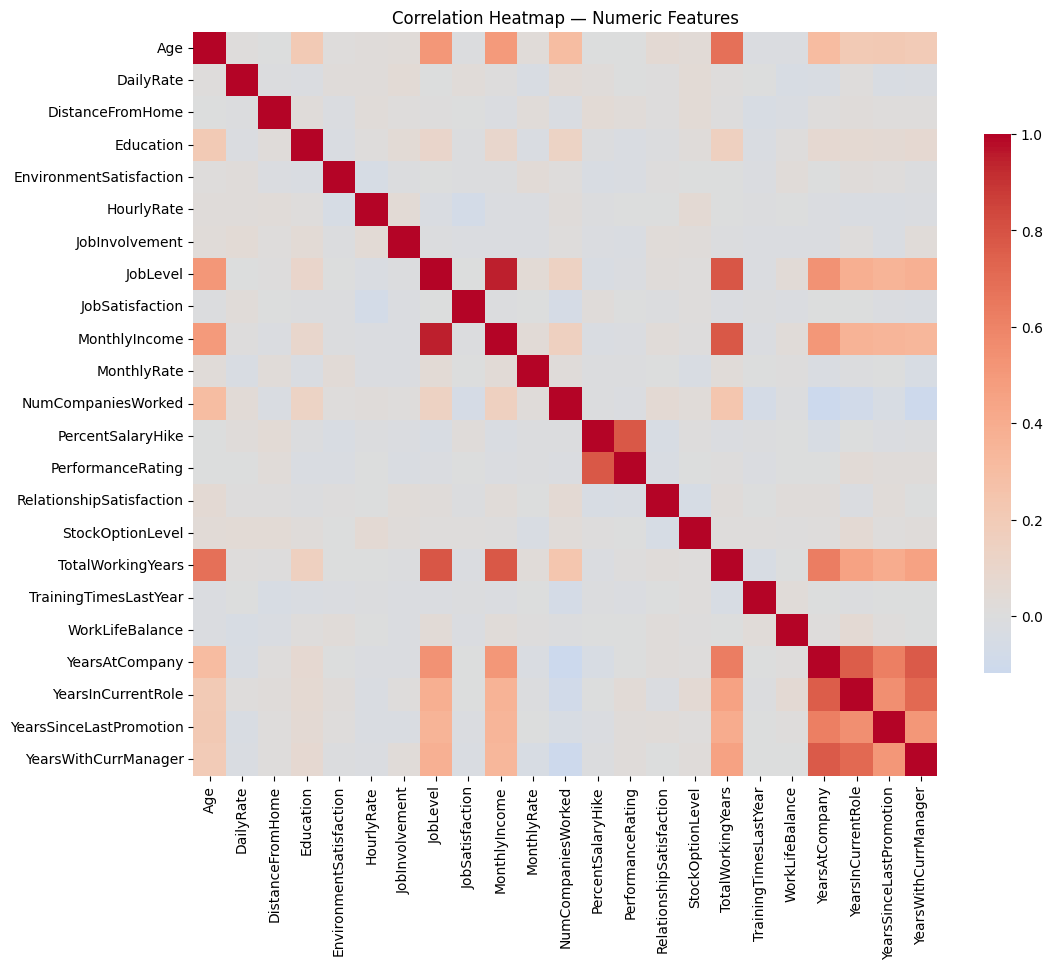

In [4]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink':0.7})
ax.set_title('Correlation Heatmap — Numeric Features')
plt.show()

## 3. Numeric features vs. Attrition

In [6]:
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)
corrs = num_df.assign(Attrition_bin=df['Attrition_bin']).corr()['Attrition_bin'].drop('Attrition_bin').sort_values()
corrs

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
PercentSalaryHike          -0.013478
HourlyRate                 -0.006846
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
Name: Attrition_bin, dtype: float64

Note: lower `TotalWorkingYears`, lower `JobLevel`, less time `InCurrentRole`, lower `MonthlyIncome`, and younger `Age` are all associated with higher attrition.

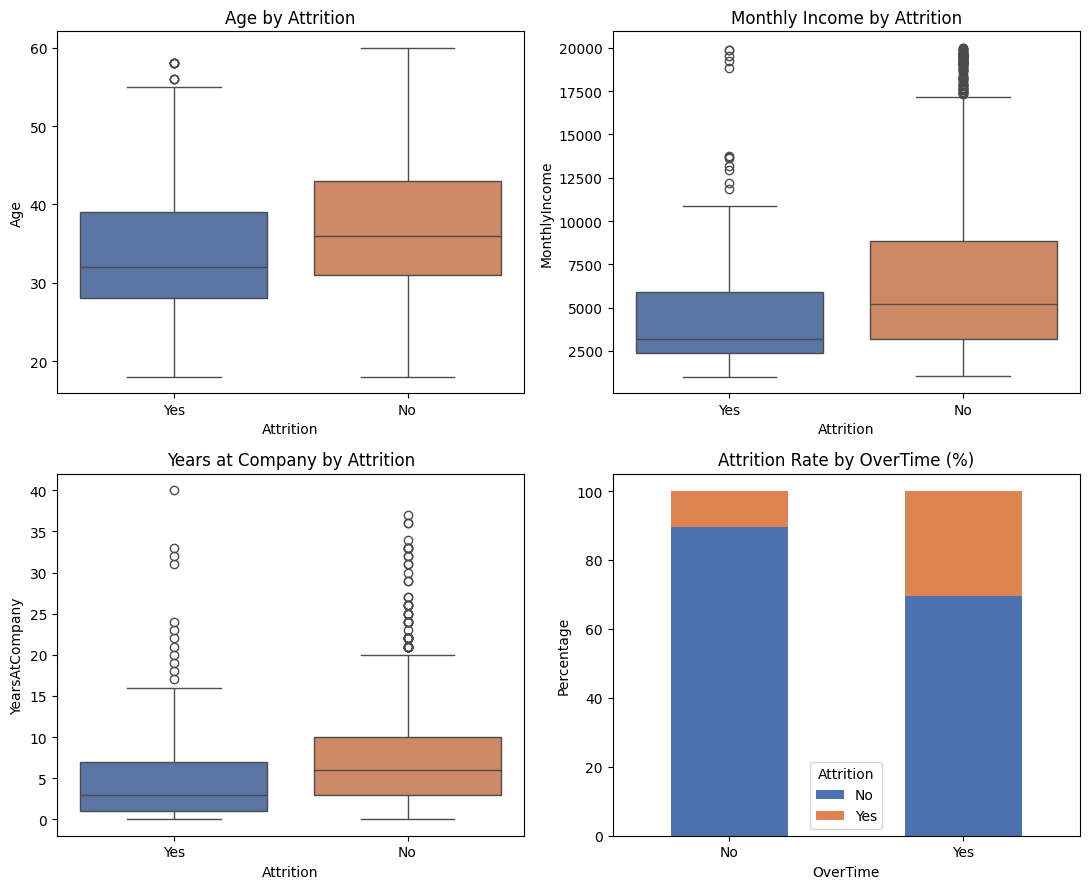

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11,9))
sns.boxplot(data=df, x='Attrition', y='Age', ax=axes[0,0], hue='Attrition', palette=['#4C72B0','#DD8452'], legend=False)
axes[0,0].set_title('Age by Attrition')

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[0,1], hue='Attrition', palette=['#4C72B0','#DD8452'], legend=False)
axes[0,1].set_title('Monthly Income by Attrition')

sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[1,0], hue='Attrition', palette=['#4C72B0','#DD8452'], legend=False)
axes[1,0].set_title('Years at Company by Attrition')

ct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#4C72B0','#DD8452'])
axes[1,1].set_title('Attrition Rate by OverTime (%)')
axes[1,1].set_ylabel('Percentage')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Categorical / behavioral drivers

In [8]:
for col in ['OverTime', 'MaritalStatus', 'BusinessTravel', 'Department']:
    print(f"\nAttrition rate by {col}:")
    print((df.groupby(col)['Attrition_bin'].mean() * 100).round(1).sort_values(ascending=False))


Attrition rate by OverTime:
OverTime
Yes    30.5
No     10.4
Name: Attrition_bin, dtype: float64

Attrition rate by MaritalStatus:
MaritalStatus
Single      25.5
Married     12.5
Divorced    10.1
Name: Attrition_bin, dtype: float64

Attrition rate by BusinessTravel:
BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0
Name: Attrition_bin, dtype: float64

Attrition rate by Department:
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition_bin, dtype: float64


## 5. Attrition by Job Role

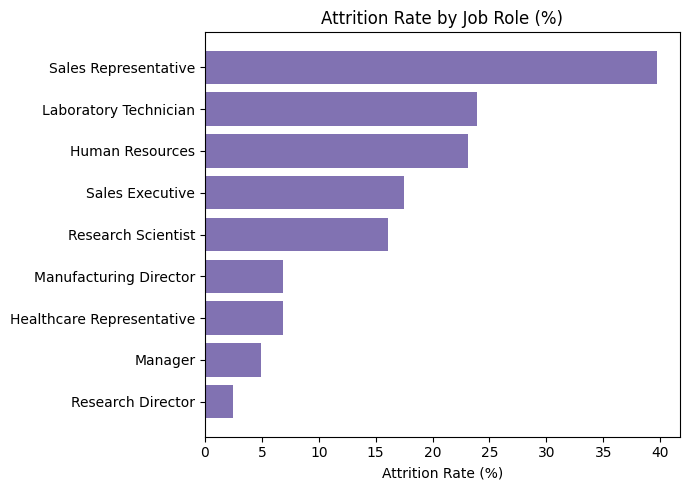

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition_bin, dtype: float64

In [9]:
role_attr = df.groupby('JobRole')['Attrition_bin'].mean().mul(100).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
ax.barh(role_attr.index, role_attr.values, color='#8172B2')
ax.set_title('Attrition Rate by Job Role (%)')
ax.set_xlabel('Attrition Rate (%)')
plt.tight_layout()
plt.show()

role_attr.sort_values(ascending=False)